### Student's Distribution

Let:

- $Z$ a random variable normal distributed $\sim \mathcal{N}(0, 1)$
- $V$ a random variable which probability density function is $\chi^2$ with $k$ degrees of freedom

The following quantity:

$$
    T = Z \, \sqrt{\frac{k}{V}}
$$

Follows the Student's distribution, or t-distribution, defined as:

$$
\frac{\Gamma\left(\frac{\nu+1}{2}\right)}{\sqrt{\pi\nu}\,\Gamma\left(\frac{\nu}{2}\right)} \left(1 + \frac{x^2}{\nu}\right)^{-\frac{\nu+1}{2}}
$$

Let's see it

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma # Gamma function

In [2]:
N = 1_000 # To compute V
k = 40 # Degrees of freedom

In [3]:
rng = np.random.default_rng()
normals = rng.standard_normal(size = (N, k), dtype = np.float32) # Matrix of normal random variables, with N rows and k columns
normals

array([[ 0.84152573,  1.1208875 , -0.4608204 , ..., -1.0417831 ,
        -1.4894705 ,  0.98560005],
       [ 0.00640473,  0.8823081 ,  0.30220816, ..., -2.10921   ,
         0.04379258,  0.49271446],
       [ 0.9229684 ,  0.91685337,  0.5855542 , ..., -0.32479623,
         1.1470499 , -0.42294347],
       ...,
       [-1.3636895 ,  1.0021919 ,  0.7756373 , ...,  0.16079806,
        -0.21224628,  0.8474753 ],
       [-0.41227603, -1.4868028 ,  1.4183267 , ...,  0.4188434 ,
         0.22311763, -0.10640597],
       [ 2.1307883 , -0.9503945 ,  1.235624  , ...,  0.85834116,
        -0.9097259 ,  0.766568  ]], shape=(1000, 40), dtype=float32)

In [4]:
Z = normals[:, 0] # Just take a row of the matrix
V = np.sum(normals ** 2, axis = 1) # Square rows, then sum each one individually to get many chi^2 random values
V

array([29.170855, 32.775986, 31.28273 , 47.52237 , 38.632072, 42.807472,
       26.298492, 44.990173, 46.853638, 30.17574 , 52.338318, 47.769844,
       39.848923, 29.089952, 37.616676, 34.446907, 30.408602, 35.871925,
       38.25947 , 39.49225 , 50.663963, 36.026615, 37.10589 , 34.116188,
       39.99672 , 30.06126 , 28.975925, 32.87109 , 35.20234 , 41.20361 ,
       46.78743 , 27.926165, 43.114838, 42.23928 , 35.27164 , 46.496998,
       39.31013 , 36.27858 , 43.24932 , 35.82613 , 38.41309 , 46.586185,
       40.993256, 45.475647, 36.208916, 48.669556, 33.0595  , 31.095404,
       52.71122 , 38.61792 , 33.377518, 36.224598, 50.405685, 28.60328 ,
       50.279335, 34.63476 , 31.096695, 43.73802 , 52.136467, 40.766556,
       40.924675, 28.677036, 50.370987, 37.806786, 32.23481 , 35.94159 ,
       28.400946, 32.896847, 36.844063, 69.32948 , 40.8108  , 44.394085,
       44.498566, 41.128242, 47.870552, 31.48199 , 31.509493, 30.562592,
       31.502281, 27.233925, 48.401367, 40.845005, 

In [5]:
T = Z * np.sqrt(k / V) # Compute T array
T

array([ 0.9854233 ,  0.00707543,  1.043673  , -0.869011  , -0.17046988,
        1.4197283 ,  0.43711767,  1.3635283 ,  0.5225756 ,  0.54704607,
        2.2135699 , -1.3752568 ,  1.8954921 ,  1.850043  , -2.34537   ,
       -1.391055  , -1.4737291 ,  0.6888686 ,  0.6611701 ,  0.4618197 ,
        0.34836757,  1.1826632 ,  0.01502556, -0.13566458,  0.26123717,
        0.8486524 ,  0.18400806,  1.0630214 , -0.56127584,  0.5087845 ,
        1.0234963 ,  1.2405219 , -1.1114582 , -1.2492675 , -0.75257325,
        0.50360525,  0.69780695,  0.94412714, -0.5195816 ,  0.64085215,
        0.43284813, -0.3848657 , -1.296998  ,  0.6714158 ,  0.0354241 ,
       -0.3342854 ,  0.03341602,  0.43798676, -0.22155297, -1.0557804 ,
       -0.68328184, -1.8528703 ,  0.07858294, -0.9178198 ,  0.21975021,
        0.734942  ,  0.23293665,  1.9707086 ,  0.93492055, -0.36996803,
        1.6226176 , -0.17996754,  1.050713  , -0.34177202,  0.7216739 ,
        0.9796344 ,  0.6717474 , -0.7798923 ,  0.10661032, -0.89

We can see that if the number of degrees of freedom is huge, the t-distribution approaches the normal distribution

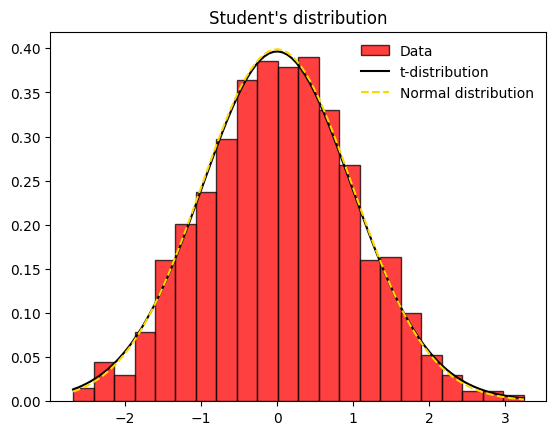

In [6]:
student = lambda x, df: (gamma((1.0 + df) / 2.0)) / (np.sqrt(np.pi * df) * gamma(df / 2.0)) * (1.0 + x ** 2 / df) ** (- (df + 1.0) / 2.0) # Student PDF
normal = lambda x: 1 / np.sqrt(2 * np.pi) * np.exp(- 0.5 * x ** 2) # Normal PDF

# Plotting results
t_array = np.linspace(np.min(T), np.max(T), 100, dtype = np.float32)

plt.title("Student's distribution")
plt.hist(T, bins = 'auto', density = True, label = 'Data', color = 'red', edgecolor = 'black', alpha = 0.75)
plt.plot(t_array, student(t_array, k).astype(np.float32), color = 'black', linestyle = '-', label = 't-distribution')
plt.plot(t_array, normal(t_array).astype(np.float32), color = 'gold', linestyle = '--', label = 'Normal distribution')
plt.legend(loc = 'best', frameon = False)
plt.show()